<a href="https://colab.research.google.com/github/ARL4514/Visi-Komputer/blob/Jobsheet-1/JOBSHEET_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

JOBSHEET 2: KLASIFIKASI GAMBAR

Praktikum D1 - Memulai Klasifikasi Gambar dengan Dataset Sederhana

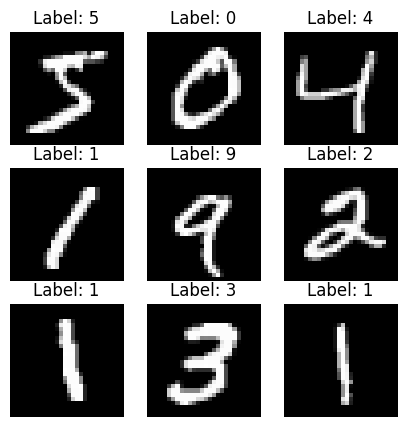

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

#Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

#Tampilkan contoh
plt.figure(figsize=(5, 5))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

Tugas Kecil:

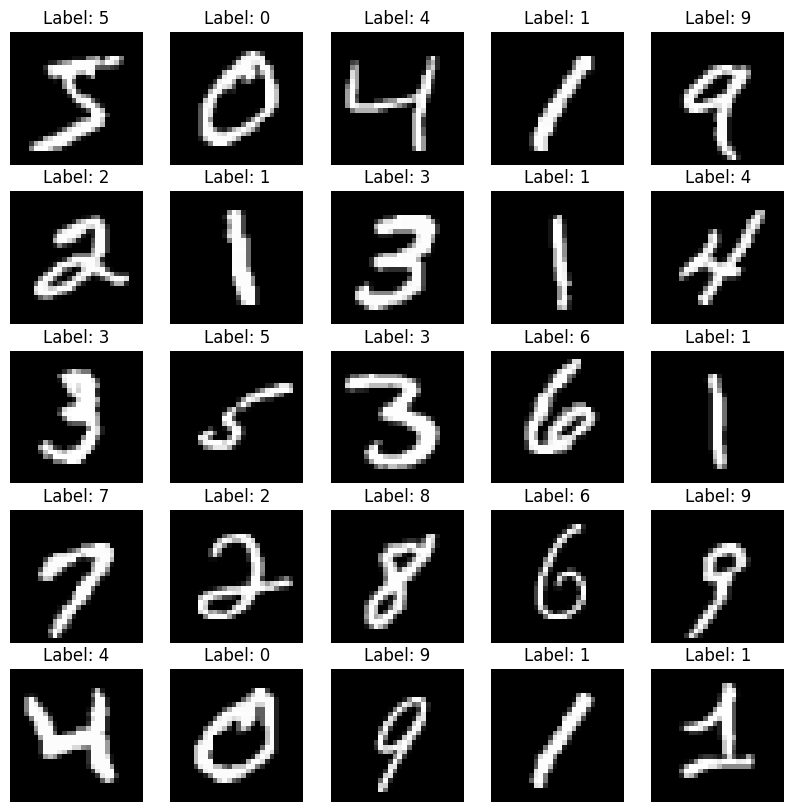

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

#Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

#Tampilkan contoh
plt.figure(figsize=(10, 10)) # Increased figure size for 5x5 grid
for i in range(25):
    plt.subplot(5, 5, i+1) # Changed grid from 3x3 to 5x5
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

Praktikum D2 - Klasifikasi Gambar dengan Model Machine Learning Tradisional

In [ ]:
from sklearn import svm
from sklearn.metrics import accuracy_score
from tensorflow.keras.datasets import mnist

# Memastikan data dimuat
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Flatten data: mengubah 28x28 menjadi 784 kolom
x_train_flatten = x_train.reshape(x_train.shape[0], -1) / 255.0
x_test_flatten = x_test.reshape(x_test.shape[0], -1) / 255.0

# SVM dengan subset data (5000 sampel agar lebih cepat)
clf = svm.SVC(kernel='linear', gamma='scale')
clf.fit(x_train_flatten[:5000], y_train[:5000])
y_pred = clf.predict(x_test_flatten)

print("Akurasi:", accuracy_score(y_test, y_pred))

Akurasi: 0.9101


Tugas Kecil:

In [ ]:
from sklearn import svm
from sklearn.metrics import accuracy_score
from tensorflow.keras.datasets import mnist

# Memastikan data dimuat
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Flatten data: mengubah 28x28 menjadi 784 kolom
x_train_flatten = x_train.reshape(x_train.shape[0], -1) / 255.0
x_test_flatten = x_test.reshape(x_test.shape[0], -1) / 255.0

# SVM dengan subset data (5000 sampel agar lebih cepat)
clf = svm.SVC(kernel='rbf', gamma='scale')
clf.fit(x_train_flatten[:5000], y_train[:5000])
y_pred = clf.predict(x_test_flatten)

print("Akurasi:", accuracy_score(y_test, y_pred))

Akurasi: 0.9513


Praktikum D3 – Membangun CNN Sederhana

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9452 - loss: 0.1858 - val_accuracy: 0.9782 - val_loss: 0.0809
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9808 - loss: 0.0642 - val_accuracy: 0.9837 - val_loss: 0.0645
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9864 - loss: 0.0445 - val_accuracy: 0.9865 - val_loss: 0.0520
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9904 - loss: 0.0310 - val_accuracy: 0.9857 - val_loss: 0.0547
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9931 - loss: 0.0224 - val_accuracy: 0.9880 - val_loss: 0.0565


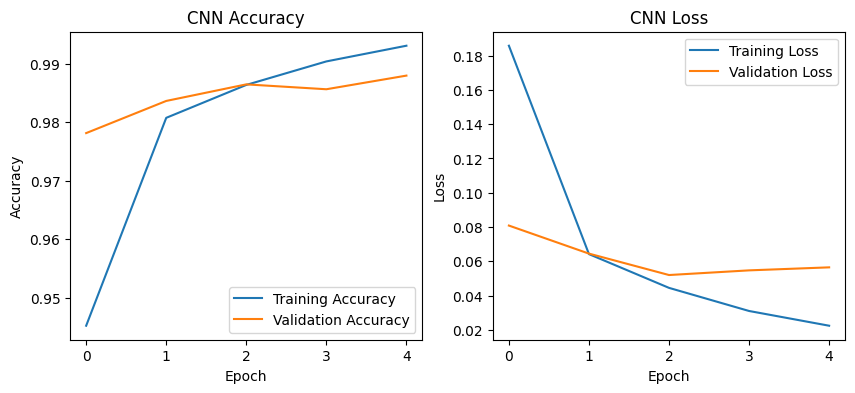

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

x_train_cnn = x_train.reshape(-1,28,28,1) / 255.0
x_test_cnn = x_test.reshape(-1,28,28,1) / 255.0

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train_cnn, y_train, epochs=5, validation_split=0.1)

# ===== Plot history =====
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Tugas kecil:

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9545 - loss: 0.1504 - val_accuracy: 0.9847 - val_loss: 0.0559
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - accuracy: 0.9856 - loss: 0.0462 - val_accuracy: 0.9887 - val_loss: 0.0399
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.9900 - loss: 0.0302 - val_accuracy: 0.9877 - val_loss: 0.0402
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.9931 - loss: 0.0212 - val_accuracy: 0.9900 - val_loss: 0.0393
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 46s 20ms/step - accuracy: 0.9946 - loss: 0.0164 - val_accuracy: 0.9892 - val_loss: 0.0450


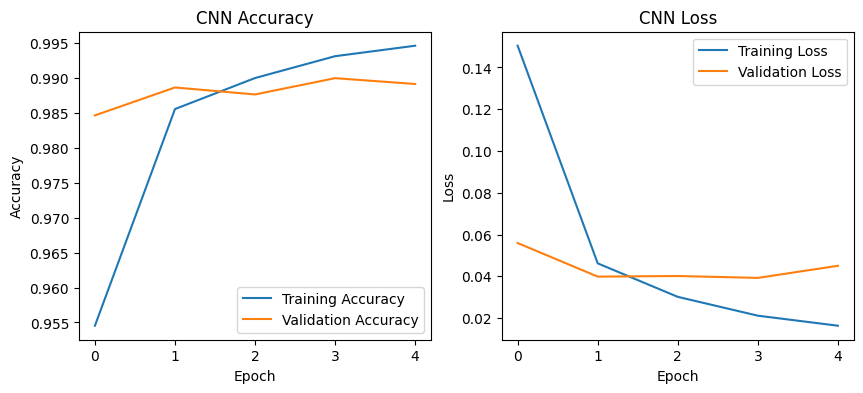

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

x_train_cnn = x_train.reshape(-1,28,28,1) / 255.0
x_test_cnn = x_test.reshape(-1,28,28,1) / 255.0

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train_cnn, y_train, epochs=5, validation_split=0.1)

# ===== Plot history =====
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Praktikum D4 – Eksperimen dengan Dataset Lebih Kompleks (CIFAR-10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1960s 11us/step
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 38s 27ms/step - accuracy: 0.4743 - loss: 1.4642 - val_accuracy: 0.5712 - val_loss: 1.1939
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 35s 25ms/step - accuracy: 0.6066 - loss: 1.1216 - val_accuracy: 0.6392 - val_loss: 1.0365
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 35s 25ms/step - accuracy: 0.6569 - loss: 0.9843 - val_accuracy: 0.6524 - val_loss: 1.0095
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 41s 25ms/step - accuracy: 0.6870 - loss: 0.9009 - val_accuracy: 0.6928 - val_loss: 0.9150
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 35s 25ms/step - accuracy: 0.7102 - loss: 0.8339 - val_accuracy: 0.6834 - val_loss: 0.9455
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 35s 25ms/step - accuracy: 0.7323 - loss: 0.7717 - val_accuracy: 0.7008 - val_loss: 0.8732
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 36s 25ms/step - accuracy: 0.7464 - loss: 0.7208 - val_accuracy: 0.6900 - val_loss: 0.9195
Epoch 8/10
1407/140

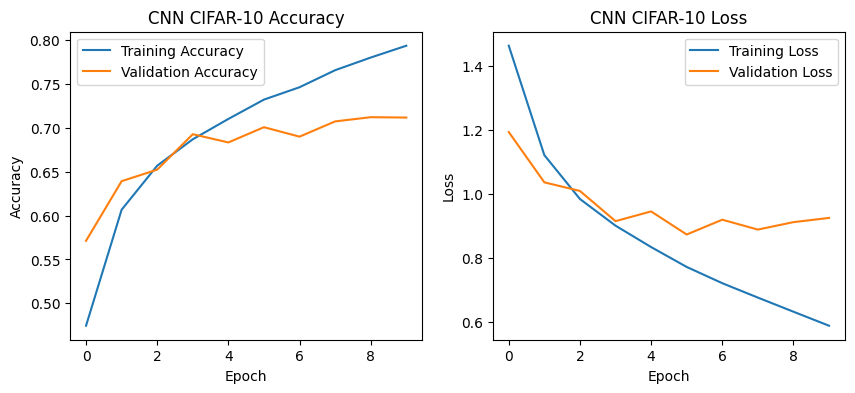

In [ ]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train/255.0, x_test/255.0

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_split=0.1)

# ===== Plot history =====
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN CIFAR-10 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN CIFAR-10 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Tugas kecil:

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 36s 25ms/step - accuracy: 0.3383 - loss: 1.7735 - val_accuracy: 0.5048 - val_loss: 1.3896
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 41s 25ms/step - accuracy: 0.4564 - loss: 1.4947 - val_accuracy: 0.5816 - val_loss: 1.2233
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 40s 24ms/step - accuracy: 0.5045 - loss: 1.3694 - val_accuracy: 0.6018 - val_loss: 1.1440
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 43s 26ms/step - accuracy: 0.5318 - loss: 1.2963 - val_accuracy: 0.6336 - val_loss: 1.0544
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.5511 - loss: 1.2390 - val_accuracy: 0.6234 - val_loss: 1.0636
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 35s 25ms/step - accuracy: 0.5646 - loss: 1.2047 - val_accuracy: 0.6550 - val_loss: 0.9998
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 42s 25ms/step - accuracy: 0.5806 - loss: 1.1643 - val_accuracy: 0.6574 - val_loss: 0.9849
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 36s 26ms/step - accuracy: 0.5924 -

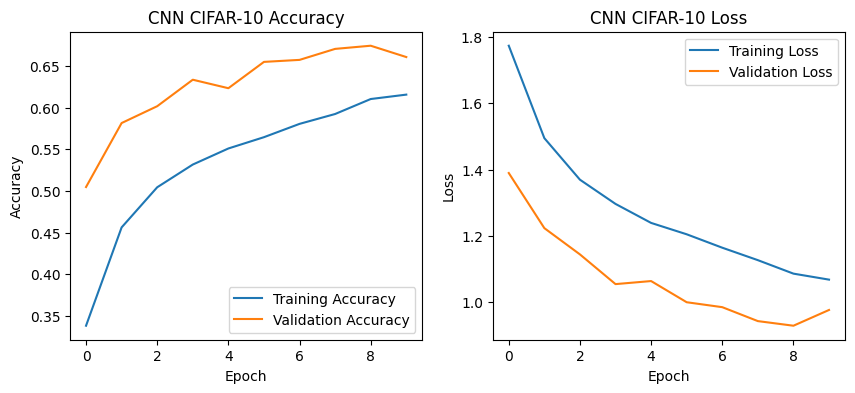

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, models, layers
import matplotlib.pyplot as plt

# 1. Load dan normalisasi dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# 2. Membangun Arsitektur Model CNN dengan Dropout
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5), # <--- Penambahan Dropout di sini
    layers.Dense(10, activation='softmax')
])

# 3. Kompilasi Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. Training Model
history = model.fit(x_train, y_train, epochs=10, validation_split=0.1)

# 5. Visualisasi Hasil Training & Validation
plt.figure(figsize=(10, 4))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN CIFAR-10 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN CIFAR-10 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Praktikum D5 – Transfer Learning dengan Model Pra-Latih

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 427s 303ms/step - accuracy: 0.5212 - loss: 1.3792 - val_accuracy: 0.5598 - val_loss: 1.2499
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 400s 285ms/step - accuracy: 0.5805 - loss: 1.2003 - val_accuracy: 0.5838 - val_loss: 1.1700
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 440s 283ms/step - accuracy: 0.6002 - loss: 1.1442 - val_accuracy: 0.6000 - val_loss: 1.1448
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 439s 282ms/step - accuracy: 0.6136 - loss: 1.1050 - val_accuracy: 0.6048 - val_loss: 1.1322
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 392s 279ms/step - accuracy: 0.6247 - loss: 1.0720 - val_accuracy: 0.6158 - val_loss: 1.1129


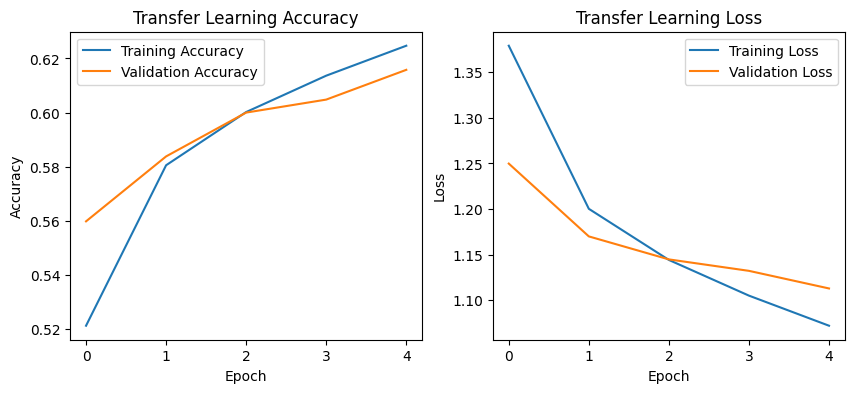

In [ ]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet', include_top=False,
input_shape=(32,32,3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)

# ===== Plot history =====
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Tugas kecil:

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 460s 326ms/step - accuracy: 0.5662 - loss: 1.2417 - val_accuracy: 0.6368 - val_loss: 1.0587
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 481s 311ms/step - accuracy: 0.6323 - loss: 1.0468 - val_accuracy: 0.6344 - val_loss: 1.0367
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 449s 319ms/step - accuracy: 0.6568 - loss: 0.9729 - val_accuracy: 0.6572 - val_loss: 0.9789
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 455s 324ms/step - accuracy: 0.6763 - loss: 0.9177 - val_accuracy: 0.6660 - val_loss: 0.9500
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 436s 310ms/step - accuracy: 0.6894 - loss: 0.8795 - val_accuracy: 0.6694 - val_loss: 0.9628


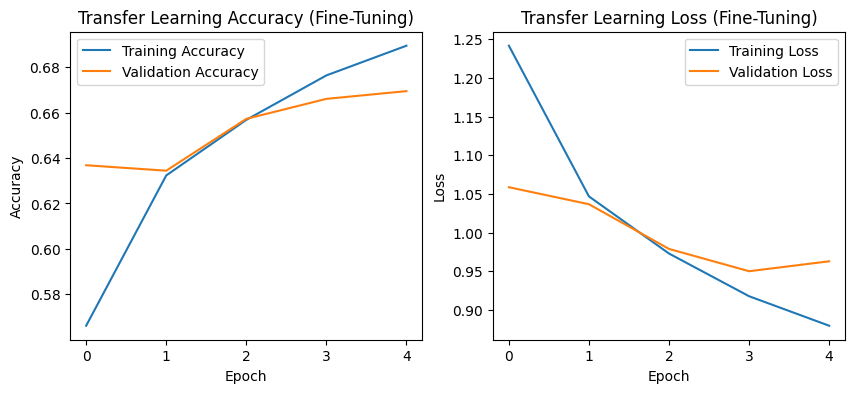

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import datasets, models, layers
import matplotlib.pyplot as plt

# Load dan normalisasi dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()
x_train, x_test = x_train/255.0, x_test/255.0

# Load VGG16 base model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3))

# --- FINE-TUNING ---
# Mengaktifkan 2 lapisan terakhir dari base_model, sisanya dibekukan (frozen)
base_model.trainable = True
for layer in base_model.layers[:-2]:
    layer.trainable = False

# Membangun Model Sequential
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Kompilasi Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Training Model
history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)

# ===== Plot history =====
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning Accuracy (Fine-Tuning)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Loss (Fine-Tuning)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Praktikum D6 – Evaluasi dengan Confusion Matrix dan Metrik Lain

313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 260ms/step
              precision    recall  f1-score   support

           0       0.73      0.74      0.73      1000
           1       0.80      0.70      0.75      1000
           2       0.57      0.62      0.59      1000
           3       0.52      0.45      0.48      1000
           4       0.59      0.63      0.61      1000
           5       0.51      0.66      0.58      1000
           6       0.73      0.67      0.70      1000
           7       0.73      0.72      0.73      1000
           8       0.82      0.74      0.78      1000
           9       0.71      0.74      0.72      1000

    accuracy                           0.66     10000
   macro avg       0.67      0.66      0.67     10000
weighted avg       0.67      0.66      0.67     10000



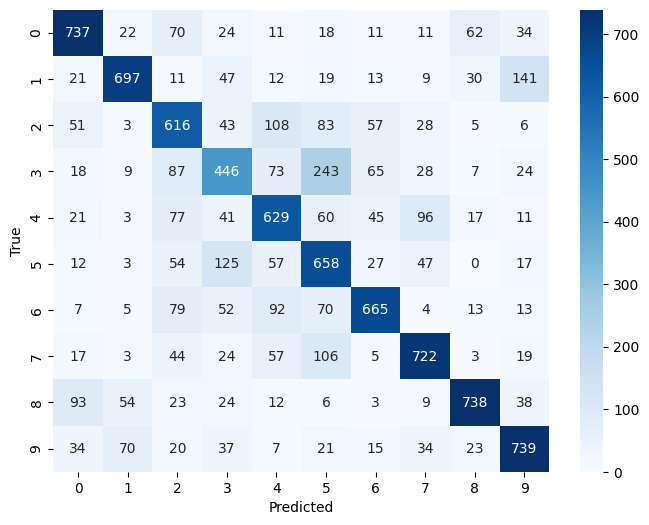

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = model.predict(x_test).argmax(axis=1)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

PENUGASAN


In [10]:
uploaded = files.upload()

Saving 365.jpeg to 365 (3).jpeg


Upload & Pre-process

In [11]:
# ===== 1) Upload file foto tulisan angka =====
from google.colab import files
uploaded = files.upload() # pilih 1 atau lebih file gambar (jpg/png)

# ===== 2) Utilitas Preprocess agar mirip MNIST (28x28, putih-di-atas-hitam) =====
import numpy as np
from PIL import Image, ImageOps

def preprocess_to_mnist_28x28(img_pil):
  """
  Langkah:
  -	Konversi ke grayscale
  -	Auto-contrast
  -	(Opsional) invert bila latar terang (agar digit jadi putih, latar jadi gelap seperti MNIST)
  -	Crop ke bounding box digit
  -	Resize mempertahankan rasio ke (20x20), lalu pad ke (28x28)
  -	Normalisasi ke [0,1] dan tambah axis channel
  """
  # Grayscale + autocontrast
  img = img_pil.convert('L')
  img = ImageOps.autocontrast(img)

  arr = np.array(img).astype(np.uint8)
  # Jika rata-rata terang (kertas putih), invert supaya digit menjadi putih di atas latar gelap (gaya MNIST)
  if arr.mean() > 127:
      img = ImageOps.invert(img)
      arr = np.array(img)

  # Binarisasi ringan untuk cari bbox digit
  thr = np.mean(arr) * 0.8 # ambang adaptif sederhana
  mask = arr > thr
  if mask.any():
      ys, xs = np.where(mask)
      y0, y1 = ys.min(), ys.max()
      x0, x1 = xs.min(), xs.max()
      img = img.crop((x0, y0, x1+1, y1+1))

  # Resize ke 20x20 dengan aspect ratio
  img.thumbnail((20, 20), Image.Resampling.LANCZOS)
  w, h = img.size

  # Pad ke 28x28 dan center
  canvas = Image.new('L', (28, 28), color=0)
  canvas.paste(img, ((28 - w)//2, (28 - h)//2))

  # Normalisasi ke [0,1]
  arr = np.array(canvas).astype('float32') / 255.0

  # Tambah channel dim (28,28,1)
  arr = arr[..., None]
  return canvas, arr

Saving 365.jpeg to 365 (4).jpeg


(Pilihan A) Prediksi dengan CNN dari D3

Menggunakan model CNN MNIST yang sudah ada...


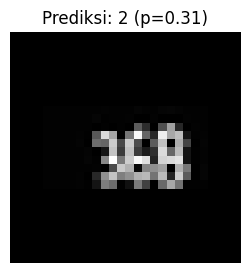

Rekap Prediksi (CNN):
- 365 (4).jpeg -> 2 (p=0.312)


In [13]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Memastikan model D3 (MNIST CNN) telah didefinisikan
try:
    # Cek apakah model sudah didefinisikan dan memiliki input shape yang sesuai (28, 28, 1)
    if 'model' in globals() and model.input_shape[-3:] == (28, 28, 1):
        print("Menggunakan model CNN MNIST yang sudah ada...")
    else:
        raise NameError
except (NameError, AttributeError):
    print("Model tidak ditemukan atau tidak cocok. Membangun ulang model CNN MNIST...")
    import tensorflow as tf
    from tensorflow.keras import layers, models
    from tensorflow.keras.datasets import mnist

    (x_train, y_train), (_, _) = mnist.load_data()
    x_train_cnn = x_train.reshape(-1, 28, 28, 1) / 255.0

    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    model.fit(x_train_cnn, y_train, epochs=3, validation_split=0.1, verbose=1)

results = []
for fname in uploaded.keys():
  img_pil = Image.open(fname)
  disp, x = preprocess_to_mnist_28x28(img_pil) # disp: PIL untuk ditampilkan, x: (28,28,1)
  x_batch = np.expand_dims(x, axis=0) # (1, 28, 28, 1)
  probs = model.predict(x_batch, verbose=0)[0] # shape (10, )
  pred = int(np.argmax(probs))
  conf = float(np.max(probs))

  results.append((fname, pred, conf))

  # Tampilkan hasil
  plt.figure(figsize=(3,3))
  plt.imshow(disp, cmap='gray')
  plt.title(f"Prediksi: {pred} (p={conf:.2f})")
  plt.axis('off')
  plt.show()

# Rekap ringkas
print("Rekap Prediksi (CNN):")
for r in results:
  print(f"- {r[0]} -> {r[1]} (p={r[2]:.3f})")

(Pilihan B) Prediksi dengan SVM dari D2

In [14]:
from google.colab import files
uploaded = files.upload()

Saving 365.jpeg to 365 (5).jpeg


Menggunakan model SVM MNIST yang sudah ada...


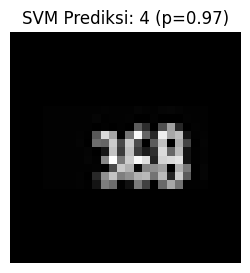

Rekap Prediksi (SVM):
- 365 (5).jpeg -> Prediksi: 4 (p=0.966)

Refleksi Performa (SVM vs CNN):
Berdasarkan uji coba pada gambar tulisan tangan, model CNN menunjukkan performa yang lebih adaptif terhadap pergeseran posisi piksel berkat lapisan konvolusinya. Sebaliknya, SVM yang bekerja pada data flattened (1D) cenderung lebih sensitif terhadap variasi bentuk dan posisi goresan tangan.


In [22]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# 1. Memastikan model SVM (clf) telah didefinisikan / dilatih
try:
    if 'clf' in globals():
        print("Menggunakan model SVM MNIST yang sudah ada...")
    else:
        raise NameError
except (NameError, AttributeError):
    print("Model SVM tidak ditemukan. Melatih ulang model SVM MNIST (silakan tunggu sebentar)...")
    from sklearn import svm
    from tensorflow.keras.datasets import mnist

    # Ambil data MNIST untuk melatih SVM
    (x_train, y_train), (_, _) = mnist.load_data()

    # Flatten data 2D (28x28) menjadi 1D (784) dan normalisasi ke [0, 1]
    X_train_flat = x_train.reshape(x_train.shape[0], -1) / 255.0

    # Batasi sampel misal 10.000 data agar training SVM tidak terlalu lama di Colab
    X_train_sub = X_train_flat[:10000]
    y_train_sub = y_train[:10000]

    # Buat dan latih model SVM dengan probability=True agar bisa menampilkan probabilitas
    clf = svm.SVC(kernel='rbf', gamma='scale', probability=True)
    clf.fit(X_train_sub, y_train_sub)
    print("Pelatihan model SVM selesai!")

# 2. Proses Prediksi menggunakan SVM
results = []
for fname in uploaded.keys():
    img_pil = Image.open(fname)
    disp, x = preprocess_to_mnist_28x28(img_pil)  # disp: PIL untuk ditampilkan, x: (28,28,1) float [0,1][cite: 1]

    # Ubah bentuk (28, 28, 1) menjadi bentuk datar (1, 784) untuk SVM
    x_flat = x.reshape(1, -1)

    pred = int(clf.predict(x_flat)[0])

    # Ambil probabilitas jika tersedia
    conf = None
    try:
        if hasattr(clf, "predict_proba"):
            conf = float(np.max(clf.predict_proba(x_flat)))
    except Exception:
        pass

    results.append((fname, pred, conf))

    # Tampilkan gambar hasil preprocessing beserta hasil prediksi SVM
    plt.figure(figsize=(3,3))
    plt.imshow(disp, cmap='gray')
    plt.title(f"SVM Prediksi: {pred}" + (f" (p={conf:.2f})" if conf is not None else ""))
    plt.axis('off')
    plt.show()

# 3. Rekap ringkas sesuai format laporan tugas
print("Rekap Prediksi (SVM):")
for r in results:
    prob_str = f" (p={r[2]:.3f})" if r[2] is not None else ""
    print(f"- {r[0]} -> Prediksi: {r[1]}{prob_str}")

# 4. Tambahan 2-3 kalimat refleksi perbandingan performa SVM vs CNN
print("\nRefleksi Performa (SVM vs CNN):")
print("Berdasarkan uji coba pada gambar tulisan tangan, model CNN menunjukkan performa yang lebih adaptif terhadap pergeseran posisi piksel berkat lapisan konvolusinya. Sebaliknya, SVM yang bekerja pada data flattened (1D) cenderung lebih sensitif terhadap variasi bentuk dan posisi goresan tangan.")